<a href="https://colab.research.google.com/github/adrmoreno1/ModelosAnaliticosUnicafam202607/blob/main/ParcialFinal_MODELO_K_MEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INTRODUCCION A PYTHON MODELOS ANALITICOS

UNICAFAM

DOCENTE: NICOLAS MOJICA

ESTUDIANTE: ADRIANA MORENO

MODELO K-MEANS

In [ ]:
#Paso 1. Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Paso 2. Importar el set de datos
dataset = pd.read_excel("/content/sample_data/crime_data.xlsx")
dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [ ]:
#Paso 3. Seleccionar las columnas para determinar el cluster
X = dataset.iloc[:, 1:5].values
X

array([[ 13.2, 236. ,  58. ,  21.2],
       [ 10. , 263. ,  48. ,  44.5],
       [  8.1, 294. ,  80. ,  31. ],
       [  8.8, 190. ,  50. ,  19.5],
       [  9. , 276. ,  91. ,  40.6],
       [  7.9, 204. ,  78. ,  38.7],
       [  3.3, 110. ,  77. ,  11.1],
       [  5.9, 238. ,  72. ,  15.8],
       [ 15.4, 335. ,  80. ,  31.9],
       [ 17.4, 211. ,  60. ,  25.8],
       [  5.3,  46. ,  83. ,  20.2],
       [  2.6, 120. ,  54. ,  14.2],
       [ 10.4, 249. ,  83. ,  24. ],
       [  7.2, 113. ,  65. ,  21. ],
       [  2.2,  56. ,  57. ,  11.3],
       [  6. , 115. ,  66. ,  18. ],
       [  9.7, 109. ,  52. ,  16.3],
       [ 15.4, 249. ,  66. ,  22.2],
       [  2.1,  83. ,  51. ,   7.8],
       [ 11.3, 300. ,  67. ,  27.8],
       [  4.4, 149. ,  85. ,  16.3],
       [ 12.1, 255. ,  74. ,  35.1],
       [  2.7,  72. ,  66. ,  14.9],
       [ 16.1, 259. ,  44. ,  17.1],
       [  9. , 178. ,  70. ,  28.2],
       [  6. , 109. ,  53. ,  16.4],
       [  4.3, 102. ,  62. ,  16.5],
 

Text(0.5, 0, 'Clusters')

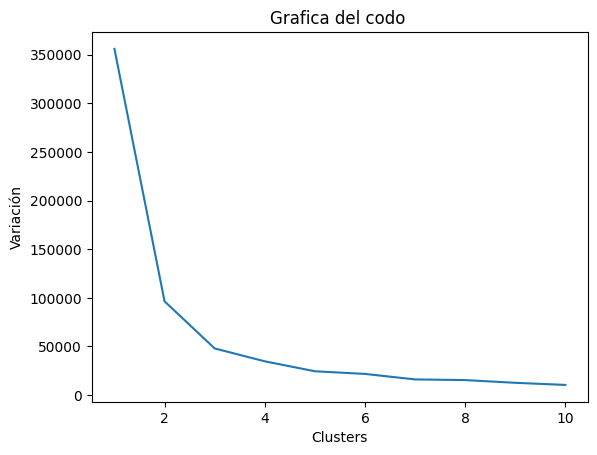

In [ ]:
#Paso 4. Definición de cantidad optima de cluster
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

#Gráfica del codo
plt.plot(range(1,11),wcss)
plt.title("Grafica del codo ")
plt.ylabel("Variación")
plt.xlabel("Clusters")

In [ ]:
#Paso 5. Entrenamiento del modelo de clusterización
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

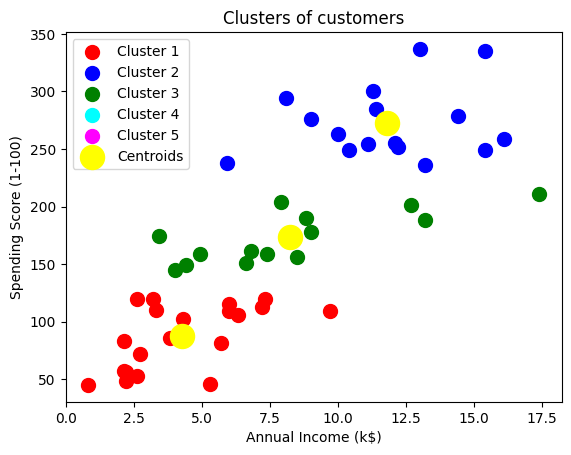

In [ ]:
#Paso 6. Visualización de resultados
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Criminalidad')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
#Paso 7: Agregar la columna al dataset
dataset["Cluster"]=y_kmeans
dataset

,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Cluster
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,1
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,2
4,California,9.0,276,91,40.6,1
5,Colorado,7.9,204,78,38.7,2
6,Connecticut,3.3,110,77,11.1,0
7,Delaware,5.9,238,72,15.8,1
8,Florida,15.4,335,80,31.9,1
9,Georgia,17.4,211,60,25.8,2


In [ ]:
#Paso 8: vamos
dataset.to_excel("Resultados.xlsx", index=False)

##1. ¿Como podemos agrupar los estados?

Cluster 1:

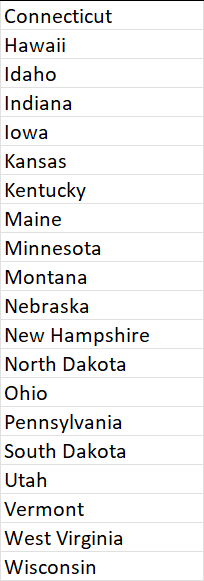

Cluster 2:

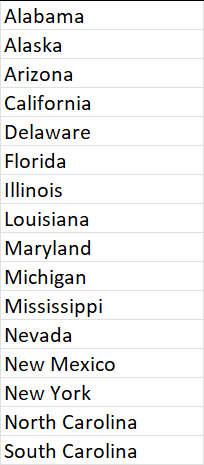

Cluster 3:

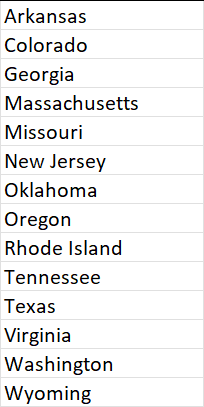

##2. ¿Cuáles son los estados con necesidad de profesionales con mayor capacidad de atención al crimen? RTA: Las ciudad del cluster 2:

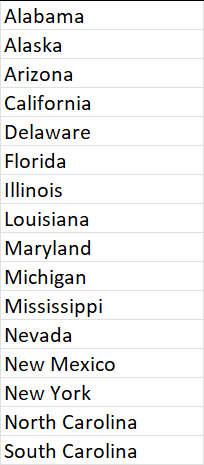

##3. ¿Cómo distribuiría los recursos?

** los policías capacitados para atender asaltos y asesinatos, que son alrededor de 300 => son para las ciudades del Cluster 2:


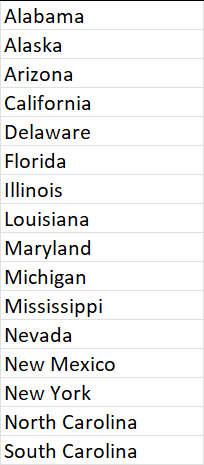

** Los policías de a pie que atienden raponazos y delincuencia común, que son alrededor de 500 => para las ciudades del cluster 3:


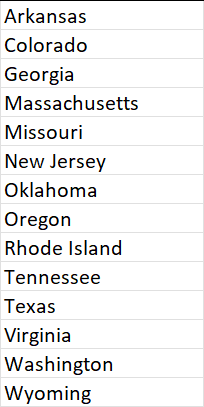

** Los cadetes, que son alrededor de 150 => Seria para atender las ciudades del cluster 1:


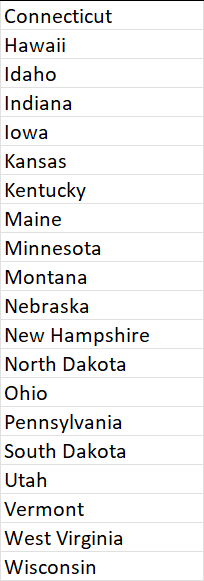

# 4. ¿Cuáles son los grupos que existen dentro del comportamiento de la criminalidad?

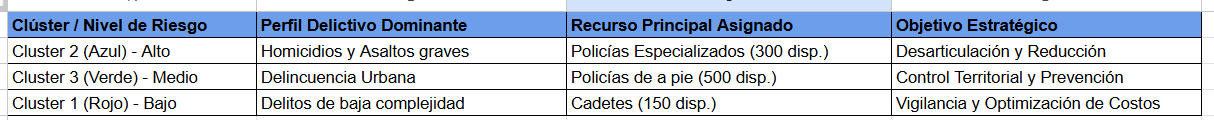

##5. Recomendaciones finales